#### The code below is a function that compares two Random Forest models with different feature sets against three baselines.
Run it first before doing the other things

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def compare_feature_sets(df, features_1, features_2, name_1="Model 1", name_2="Model 2"):
    """
    Compares two Random Forest models with different feature sets against three baselines.
    
    Parameters:
    - df: Pre-processed DataFrame (must include 'tickets_scanned', 'season', 'opponent_avg', 'same_fixture_baseline')
    - features_1: List of column names for the first model
    - features_2: List of column names for the second model
    - name_1: Label for the first model in the plot/logs
    - name_2: Label for the second model in the plot/logs
    """
    
    seasons = sorted(df["season"].unique())
    season_results = []
    
    # Identify the union of all necessary columns so we drop NaNs fairly (apples-to-apples comparison)
    required_cols = list(set(features_1 + features_2 + ["tickets_scanned", "season", "opponent_avg", "same_fixture_baseline"]))
    df_clean = df.dropna(subset=required_cols).copy()

    print(f"{'='*80}")
    print(f"FEATURE SET COMPARISON: {name_1} vs {name_2}")
    print(f"{'='*80}")

    for test_season in seasons:
        train = df_clean[df_clean["season"] != test_season].copy()
        test  = df_clean[df_clean["season"] == test_season].copy()

        if len(train) < 10 or len(test) < 5:
            continue

        y_train = train["tickets_scanned"]
        y_test  = test["tickets_scanned"]

        # --- AUTOMATIC CATEGORICAL ENCODING ---
        # Feature Set 1
        cat_cols_1 = train[features_1].select_dtypes(exclude=[np.number]).columns.tolist()
        X_train_1 = pd.get_dummies(train[features_1], columns=cat_cols_1, drop_first=True)
        X_test_1  = pd.get_dummies(test[features_1], columns=cat_cols_1, drop_first=True)
        X_test_1  = X_test_1.reindex(columns=X_train_1.columns, fill_value=0)

        # Feature Set 2
        cat_cols_2 = train[features_2].select_dtypes(exclude=[np.number]).columns.tolist()
        X_train_2 = pd.get_dummies(train[features_2], columns=cat_cols_2, drop_first=True)
        X_test_2  = pd.get_dummies(test[features_2], columns=cat_cols_2, drop_first=True)
        X_test_2  = X_test_2.reindex(columns=X_train_2.columns, fill_value=0)

        # --- BASELINES ---
        season_avg_val = train["tickets_scanned"].mean()
        pred_season   = np.full(shape=len(y_test), fill_value=season_avg_val)
        pred_opponent = test["opponent_avg"]
        pred_fixture  = test["same_fixture_baseline"]

        # --- MODEL TRAINING ---
        rf = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
        
        rf.fit(X_train_1, y_train)
        pred_m1 = rf.predict(X_test_1)
        
        rf.fit(X_train_2, y_train)
        pred_m2 = rf.predict(X_test_2)

        # --- METRICS CALCULATION (MAE & Largest Error) ---
        def get_metrics(y_true, y_pred):
            mae = mean_absolute_error(y_true, y_pred)
            max_err = np.max(np.abs(y_true - y_pred))
            return mae, max_err

        mae_seas, err_seas = get_metrics(y_test, pred_season)
        mae_opp,  err_opp  = get_metrics(y_test, pred_opponent)
        mae_fix,  err_fix  = get_metrics(y_test, pred_fixture)
        mae_m1,   err_m1   = get_metrics(y_test, pred_m1)
        mae_m2,   err_m2   = get_metrics(y_test, pred_m2)

        # Save for plotting
        season_results.append({
            "season": test_season,
            "Baseline: Season Avg": mae_seas,
            "Baseline: Opponent Avg": mae_opp,
            "Baseline: Same Fixture": mae_fix,
            name_1: mae_m1,
            name_2: mae_m2
        })

        # Print detailed logs for this season
        print(f"\n--- SEASON: {test_season} (n={len(y_test)} matches) ---")
        print(f"{'Model / Baseline':<25} | {'MAE':<8} | {'Largest Error':<13}")
        print("-" * 52)
        print(f"{'Baseline: Season Avg':<25} | {mae_seas:<8.0f} | {err_seas:<13.0f}")
        print(f"{'Baseline: Opponent Avg':<25} | {mae_opp:<8.0f} | {err_opp:<13.0f}")
        print(f"{'Baseline: Same Fixture':<25} | {mae_fix:<8.0f} | {err_fix:<13.0f}")
        print(f"{name_1:<25} | {mae_m1:<8.0f} | {err_m1:<13.0f}")
        print(f"{name_2:<25} | {mae_m2:<8.0f} | {err_m2:<13.0f}")

    # --- VISUALIZATION ---
    results_df = pd.DataFrame(season_results).set_index("season")
    cols = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", name_1, name_2]
    
    # Colors: Greys for baselines, Dark Green for Model 1, Navy Blue for Model 2
    colors = ["#d9d9d9", "#bdbdbd", "#969696", "#2ca02c", "#1f77b4"]

    x = np.arange(len(results_df))
    width = 0.15 # Thinner bars to fit 5 per group

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot each bar with an offset so they group side-by-side
    offsets = [-2*width, -width, 0, width, 2*width]
    for i, (col, color) in enumerate(zip(cols, colors)):
        ax.bar(x + offsets[i], results_df[col], width=width, label=col, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(results_df.index, rotation=0)
    ax.set_ylabel("Mean Absolute Error (MAE)")
    ax.set_title(f"Model Comparison: {name_1} vs {name_2} (MAE per Season)")
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

#### 1. THE SANDBOX: FEATURE ENGINEERING

In [ ]:
df = df.sort_values("match_date").reset_index(drop=True)

df["last_home_attendance"] = df["tickets_scanned"].shift(1)

df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(window=3).mean()

df["opponent_avg"] = df.groupby("away_team")["tickets_scanned"].transform(lambda x: x.shift().expanding().mean())
df["season_expanding_avg"] = df["tickets_scanned"].shift().expanding().mean()
df["opponent_avg"] = df["opponent_avg"].fillna(df["season_expanding_avg"])

df["school_holiday_name"] = df["school_holiday_name"].fillna("None")

df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])



#### 2. THE MENU: DEFINE YOUR FEATURE LISTS

In [ ]:
features_basic = [
    "opponent_avg",
    "last_home_attendance",
    "is_weekend"
]

features_custom = [
    "opponent_avg",
    "last_home_attendance",
    "rolling_avg_3",
    "matchday",
    "is_weekend",
    "academic_week",
    "stage",
    "school_holiday_name"
]

#### 3. THE TEST: RUN THE COMPARISON

FEATURE SET COMPARISON: Base Model vs New Attempt

--- SEASON: 2022/2023 (n=13 matches) ---
Model / Baseline          | MAE      | Largest Error
----------------------------------------------------
Baseline: Season Avg      | 1828     | 3854         
Baseline: Opponent Avg    | 2068     | 4830         
Baseline: Same Fixture    | 2068     | 4830         
Base Model                | 1731     | 4477         
New Attempt               | 1629     | 3972         

--- SEASON: 2023/2024 (n=19 matches) ---
Model / Baseline          | MAE      | Largest Error
----------------------------------------------------
Baseline: Season Avg      | 2321     | 4595         
Baseline: Opponent Avg    | 2761     | 5378         
Baseline: Same Fixture    | 2911     | 5378         
Base Model                | 1684     | 3770         
New Attempt               | 1693     | 3654         

--- SEASON: 2024/2025 (n=20 matches) ---
Model / Baseline          | MAE      | Largest Error
-----------------------------

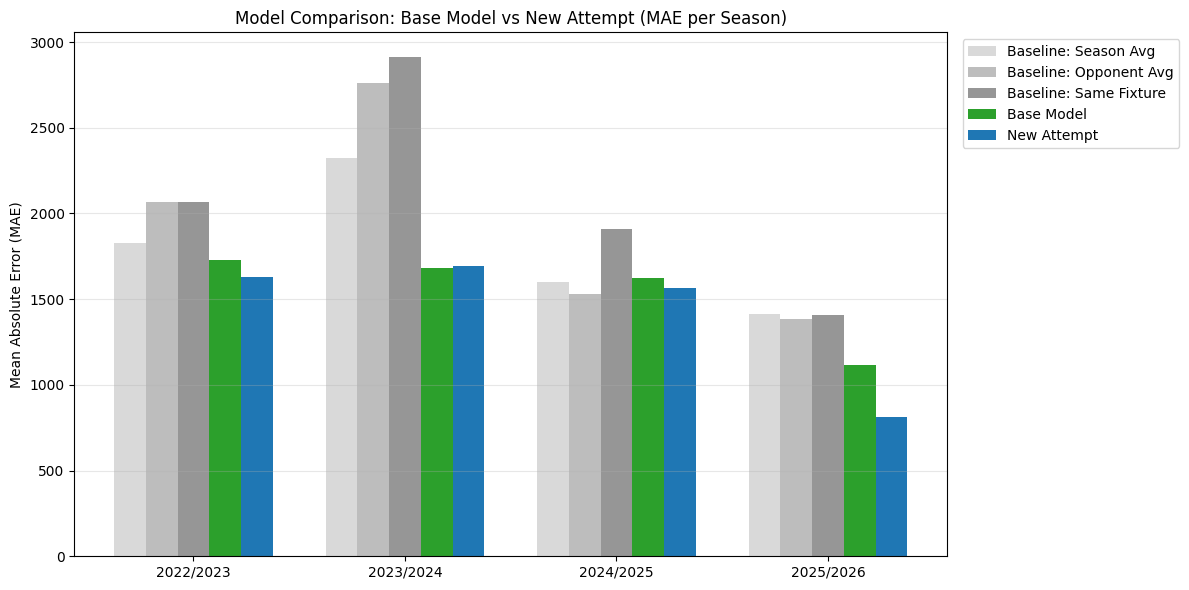

In [6]:
compare_feature_sets(
    df=df, 
    features_1=features_basic, 
    features_2=features_custom, 
    name_1="Base Model", 
    name_2="New Attempt"
)